## QSER Atmosphere Radon Paper code

## Lithosphere atmosphere section results

TRUE PARAMETERS
C_inf = 476190476.19 Bq/m³
a = 0.2002 m⁻¹
F = 1000.00 Bq/m³/min
v = 0.0100 m/min
D = 0.0500 m²/min
lambda = 2.10e-06 min⁻¹

RECOVERY FROM QSER DECOMPOSITION

1. F from C_inf:
   True F = 1000.00
   Recovered F = 1000.00

2. v from slope of S:
   Slope of S = 100000.0000
   True v = 0.0100
   Recovered v = 0.0100

3. a from E(z):
   True a = 0.2002
   Recovered a = 0.2002

4. D from a and v:
   True D = 0.0500
   Recovered D = 0.0499

RECOVERY SUMMARY
 Parameter         True    Recovered    Error (%)
------------------------------------------------------------
         F      1000.00      1000.00        0.00
         v       0.0100       0.0100        0.00
         a       0.2002       0.2002        0.00
         D       0.0500       0.0499        0.21


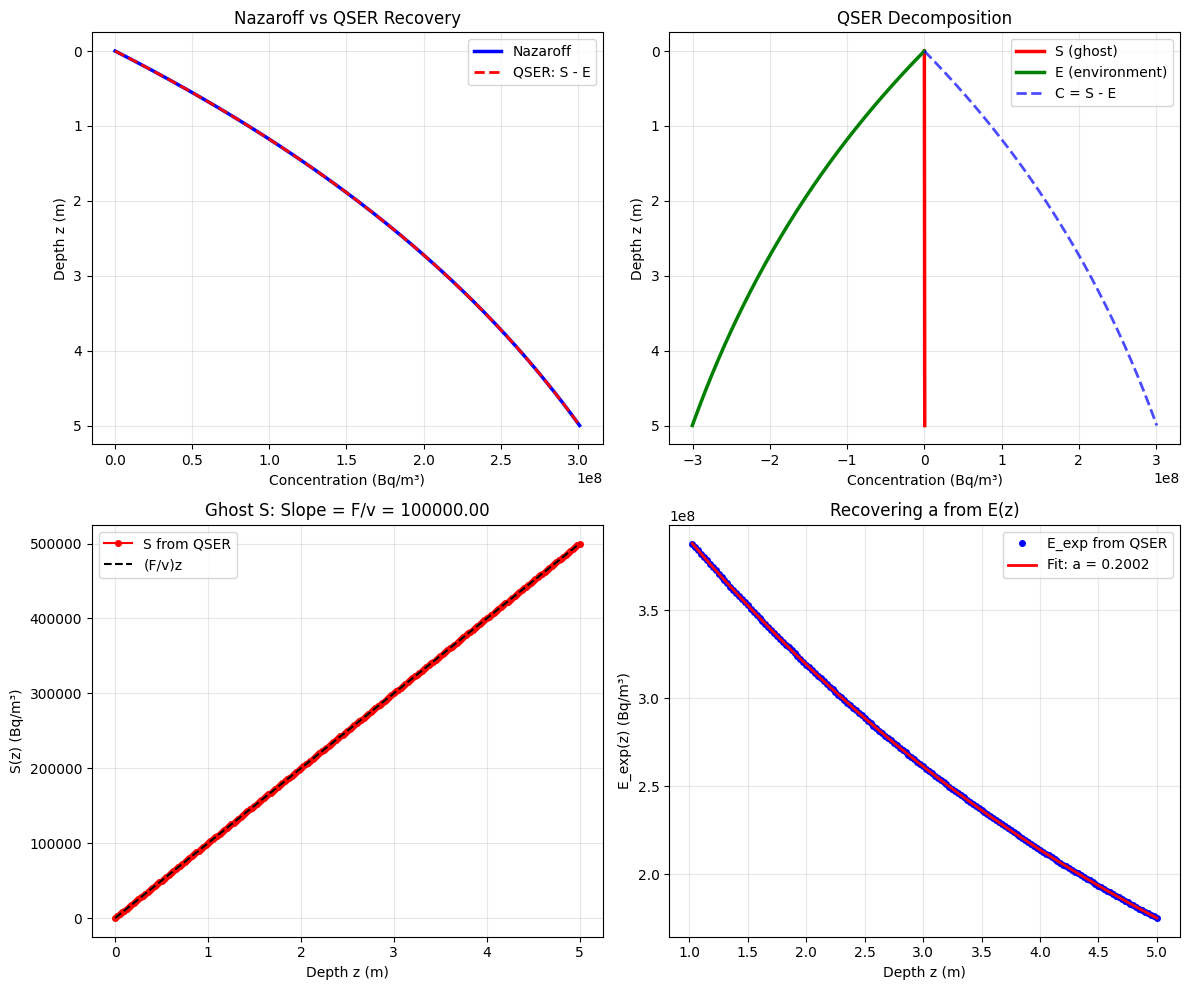


Saved to nazaroff_qser_recovery.csv


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================
# TRUE PARAMETERS
# ============================================

params_true = {
    'D': 0.05,
    'v': 0.01,
    'lambda': 2.1e-6,
    'F': 1000.0,
    'H': 5.0,
}

params_true['C_inf'] = params_true['F'] / params_true['lambda']
params_true['a'] = (params_true['v'] / (2 * params_true['D']) + 
                    np.sqrt(params_true['v']**2 / (4 * params_true['D']**2) + 
                            params_true['lambda'] / params_true['D']))

print("="*60)
print("TRUE PARAMETERS")
print("="*60)
print(f"C_inf = {params_true['C_inf']:.2f} Bq/m³")
print(f"a = {params_true['a']:.4f} m⁻¹")
print(f"F = {params_true['F']:.2f} Bq/m³/min")
print(f"v = {params_true['v']:.4f} m/min")
print(f"D = {params_true['D']:.4f} m²/min")
print(f"lambda = {params_true['lambda']:.2e} min⁻¹")

# Depth grid
z = np.linspace(0, params_true['H'], 201)

# ============================================
# NAZAROFF SOLUTION
# ============================================

C_nazaroff = params_true['C_inf'] * (1 - np.exp(-params_true['a'] * z))

# ============================================
# QSER DECOMPOSITION
# ============================================

S_ghost = (params_true['F'] / params_true['v']) * z
E_environment = S_ghost - C_nazaroff

# ============================================
# RECOVERY FROM QSER
# ============================================

print("\n" + "="*60)
print("RECOVERY FROM QSER DECOMPOSITION")
print("="*60)

# 1. Recover F from C_inf
F_recovered = params_true['lambda'] * params_true['C_inf']
print(f"\n1. F from C_inf:")
print(f"   True F = {params_true['F']:.2f}")
print(f"   Recovered F = {F_recovered:.2f}")

# 2. Recover v from slope of S
slope = (S_ghost[-1] - S_ghost[0]) / (z[-1] - z[0])
v_recovered = F_recovered / slope
print(f"\n2. v from slope of S:")
print(f"   Slope of S = {slope:.4f}")
print(f"   True v = {params_true['v']:.4f}")
print(f"   Recovered v = {v_recovered:.4f}")

# 3. Recover a from E(z)
# E(z) = (F/v)*z - C_inf + C_inf * exp(-a*z)
# So: E(z) - (F/v)*z + C_inf = C_inf * exp(-a*z)
# Take log: ln(C_inf) - a*z = ln(E - (F/v)*z + C_inf)
# Actually, simpler: fit exponential to the tail

def exp_decay(z, a, A):
    return A * np.exp(-a * z)

# Use the exponential part of E
A_true = params_true['C_inf']
E_exp = E_environment - (params_true['F'] / params_true['v']) * z + params_true['C_inf']

# Fit only the region where exponential dominates (z > 1 m)
mask = z > 1.0
popt, _ = curve_fit(exp_decay, z[mask], E_exp[mask], p0=[params_true['a'], A_true])
a_recovered = popt[0]

print(f"\n3. a from E(z):")
print(f"   True a = {params_true['a']:.4f}")
print(f"   Recovered a = {a_recovered:.4f}")

# 4. Recover D from a and v
D_recovered = v_recovered / a_recovered - params_true['lambda'] / a_recovered**2
print(f"\n4. D from a and v:")
print(f"   True D = {params_true['D']:.4f}")
print(f"   Recovered D = {D_recovered:.4f}")

# ============================================
# ERROR ANALYSIS
# ============================================

print("\n" + "="*60)
print("RECOVERY SUMMARY")
print("="*60)
print(f"{'Parameter':>10} {'True':>12} {'Recovered':>12} {'Error (%)':>12}")
print("-"*60)
print(f"{'F':>10} {params_true['F']:>12.2f} {F_recovered:>12.2f} {abs(F_recovered-params_true['F'])/params_true['F']*100:>11.2f}")
print(f"{'v':>10} {params_true['v']:>12.4f} {v_recovered:>12.4f} {abs(v_recovered-params_true['v'])/params_true['v']*100:>11.2f}")
print(f"{'a':>10} {params_true['a']:>12.4f} {a_recovered:>12.4f} {abs(a_recovered-params_true['a'])/params_true['a']*100:>11.2f}")
print(f"{'D':>10} {params_true['D']:>12.4f} {D_recovered:>12.4f} {abs(D_recovered-params_true['D'])/params_true['D']*100:>11.2f}")

# ============================================
# PLOTTING
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Nazaroff vs QSER Recovery
ax = axes[0, 0]
ax.plot(C_nazaroff, z, 'b-', linewidth=2.5, label='Nazaroff')
ax.plot(S_ghost - E_environment, z, 'r--', linewidth=2, label='QSER: S - E')
ax.set_xlabel('Concentration (Bq/m³)')
ax.set_ylabel('Depth z (m)')
ax.set_title('Nazaroff vs QSER Recovery')
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3)

# 2. QSER Decomposition
ax = axes[0, 1]
ax.plot(S_ghost, z, 'r-', linewidth=2.5, label='S (ghost)')
ax.plot(E_environment, z, 'g-', linewidth=2.5, label='E (environment)')
ax.plot(C_nazaroff, z, 'b--', linewidth=2, alpha=0.7, label='C = S - E')
ax.set_xlabel('Concentration (Bq/m³)')
ax.set_ylabel('Depth z (m)')
ax.set_title('QSER Decomposition')
ax.invert_yaxis()
ax.legend()
ax.grid(True, alpha=0.3)

# 3. S vs F/v * z (to show linearity)
ax = axes[1, 0]
ax.plot(z, S_ghost, 'ro-', markersize=4, label='S from QSER')
ax.plot(z, (params_true['F'] / params_true['v']) * z, 'k--', linewidth=1.5, label='(F/v)z')
ax.set_xlabel('Depth z (m)')
ax.set_ylabel('S(z) (Bq/m³)')
ax.set_title(f'Ghost S: Slope = F/v = {slope:.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Exponential fit for a
ax = axes[1, 1]
ax.plot(z[mask], E_exp[mask], 'bo', markersize=4, label='E_exp from QSER')
ax.plot(z[mask], exp_decay(z[mask], a_recovered, A_true), 'r-', linewidth=2, 
        label=f'Fit: a = {a_recovered:.4f}')
ax.set_xlabel('Depth z (m)')
ax.set_ylabel('E_exp(z) (Bq/m³)')
ax.set_title(f'Recovering a from E(z)')
ax.legend()
ax.grid(True, alpha=0.3)



# ============================================
# SAVE DATA
# ============================================

df = pd.DataFrame({
    'depth_m': z,
    'C_nazaroff': C_nazaroff,
    'S_ghost': S_ghost,
    'E_environment': E_environment,
    'C_recovered': S_ghost - E_environment,
    'S_fit': (params_true['F'] / params_true['v']) * z,
    'E_exp': E_exp,
    'E_exp_fit': exp_decay(z, a_recovered, A_true),
})
df.to_csv('nazaroff_qser_recovery.csv', index=False)
print("\nSaved to nazaroff_qser_recovery.csv")

## Figure 3, environment field

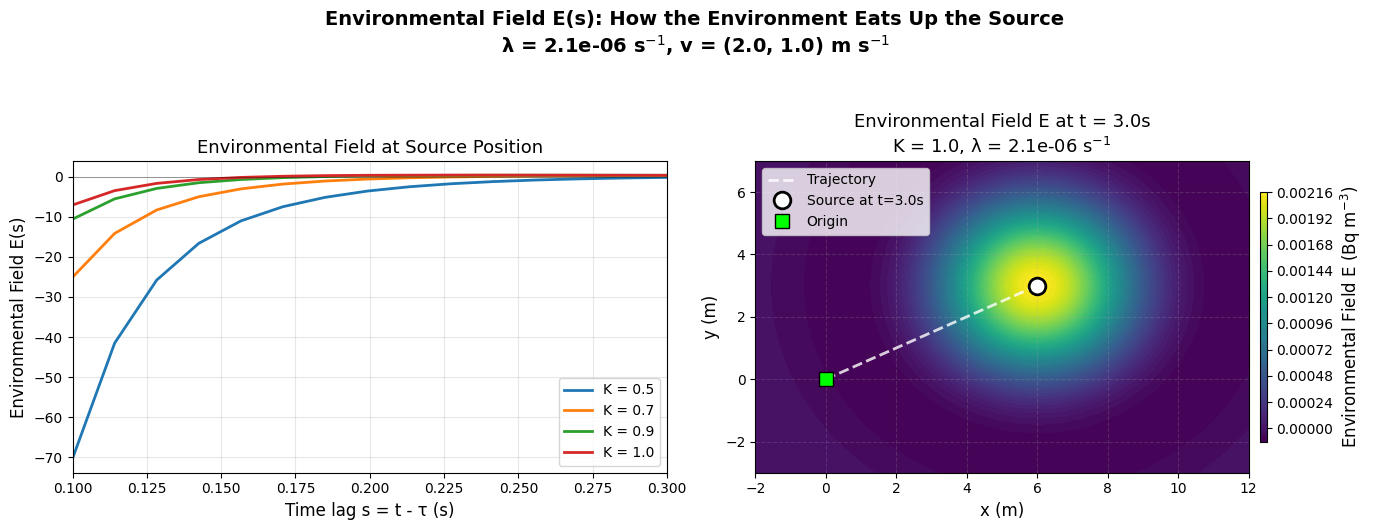

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
F0 = 1.0
lambd = 2.1e-6  # Radon-222 decay constant (s^-1)
vx, vy = 2.0, 1.0
x0, y0 = 0.0, 0.0

# Time lags - start from larger value to avoid singularities
s = np.linspace(0.1, 10, 700)

# Diffusion coefficients to vary
K_values = [0.5, 0.7, 0.9, 1.0]

# Detector position
x_det, y_det = 5.0, 3.0

# Figure: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================
# Left Plot: Environmental Field E(s) at Different K
# ============================================
ax = axes[0]

# At the source position (x = x0, y = y0)
for K in K_values:
    # E accumulates the dissipative term L_d S acting on the source
    # L_d S = -K ∇²S + λS. For a Gaussian source, this gives the bracket term
    bracket = -1 / (4 * K * s**2) + 3 / (2 * s) + lambd
    E = 1 / (4 * np.pi * K * s)**(3/2) * np.exp(-lambd * s) * bracket
    ax.plot(s, E, label=f'K = {K}', linewidth=2)

ax.set_xlabel('Time lag s = t - τ (s)', fontsize=12)
ax.set_ylabel('Environmental Field E(s)', fontsize=12)
ax.set_title('Environmental Field at Source Position', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(0.1, 0.3)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# ============================================
# Right Plot: 2D Environmental Field with Trajectory
# ============================================
ax = axes[1]

# Create grid
x = np.linspace(-2, 12, 200)
y = np.linspace(-3, 7, 200)
X, Y = np.meshgrid(x, y)

# Fixed time
t_fixed = 3.0
K_fixed = 1.0

# Source position at time t
xs = x0 + vx * t_fixed
ys = y0 + vy * t_fixed

# Calculate E at fixed time (integrated over all past emissions)
# For visualization, we compute E as the accumulated dissipative effect
r2 = (X - xs)**2 + (Y - ys)**2
bracket = -r2 / (4 * K_fixed * t_fixed**2) + 3 / (2 * t_fixed) + lambd
E_field = F0 / (4 * np.pi * K_fixed * t_fixed)**(3/2) * np.exp(-r2 / (4 * K_fixed * t_fixed)) * np.exp(-lambd * t_fixed) * bracket

# Plot E with contour
im = ax.contourf(X, Y, E_field, levels=60, cmap='viridis')

# Add trajectory
traj_x = np.linspace(x0, xs, 50)
traj_y = np.linspace(y0, ys, 50)
ax.plot(traj_x, traj_y, '--', color='white', linewidth=2, alpha=0.8, label='Trajectory')

# Source position
ax.plot(xs, ys, 'o', color='white', markersize=12, markeredgewidth=2, markeredgecolor='black', label='Source at t=3.0s')
ax.plot(x0, y0, 's', color='lime', markersize=10, markeredgecolor='black', label='Origin')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, aspect=40, shrink=0.8)
cbar.set_label('Environmental Field E (Bq m$^{-3}$)', fontsize=12)

ax.set_xlabel('x (m)', fontsize=12)
ax.set_ylabel('y (m)', fontsize=12)
ax.set_title(f'Environmental Field E at t = {t_fixed:.1f}s\nK = {K_fixed}, λ = {lambd:.1e} s$^{{-1}}$', fontsize=13)
ax.set_xlim(-2, 12)
ax.set_ylim(-3, 7)
ax.grid(True, linestyle='--', alpha=0.2)
ax.legend(loc='upper left', fontsize=10)

plt.suptitle('Environmental Field E(s): How the Environment Eats Up the Source\n'
             f'λ = {lambd:.1e} s$^{{-1}}$, v = ({vx:.1f}, {vy:.1f}) m s$^{{-1}}$', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()



## Figure 2, memory field

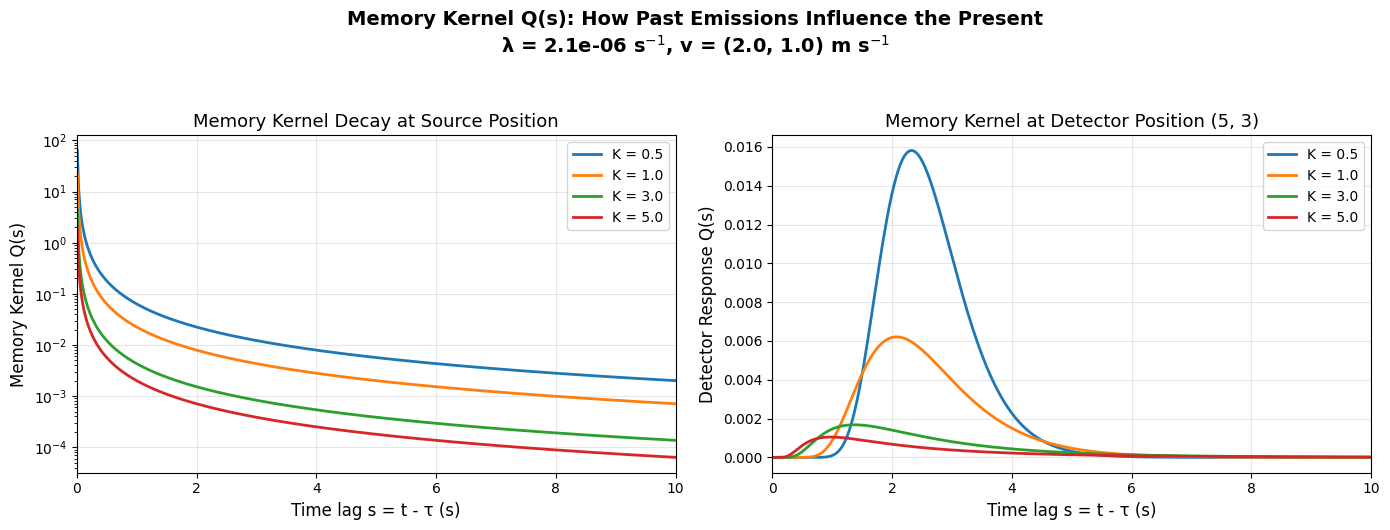

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
F0 = 1.0
lambd = 2.1e-6  # Radon-222 decay constant (s^-1)
vx, vy = 2.0, 1.0
x0, y0 = 0.0, 0.0

# Time lags
s = np.linspace(0.01, 10, 500)

# Diffusion coefficients to vary
K_values = [0.5, 1.0, 3.0, 5.0]

# Detector position
x_det, y_det = 5.0, 3.0

# Figure: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================
# Left Plot: Memory Kernel Q(s) at Different K
# ============================================
ax = axes[0]

# At the source position (x = x0, y = y0)
for K in K_values:
    Q = 1 / (4 * np.pi * K * s)**(3/2) * np.exp(-lambd * s)
    ax.plot(s, Q, label=f'K = {K}', linewidth=2)

ax.set_xlabel('Time lag s = t - τ (s)', fontsize=12)
ax.set_ylabel('Memory Kernel Q(s)', fontsize=12)
ax.set_title('Memory Kernel Decay at Source Position', fontsize=13)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(0, 10)

# ============================================
# Right Plot: Detector Response at Different K
# ============================================
ax = axes[1]

for K in K_values:
    xs = x0 + vx * s
    ys = y0 + vy * s
    r2 = (x_det - xs)**2 + (y_det - ys)**2
    Q_det = 1 / (4 * np.pi * K * s)**(3/2) * np.exp(-r2 / (4 * K * s)) * np.exp(-lambd * s)
    ax.plot(s, Q_det, label=f'K = {K}', linewidth=2)

ax.set_xlabel('Time lag s = t - τ (s)', fontsize=12)
ax.set_ylabel('Detector Response Q(s)', fontsize=12)
ax.set_title(f'Memory Kernel at Detector Position ({x_det:.0f}, {y_det:.0f})', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(0, 10)

plt.suptitle('Memory Kernel Q(s): How Past Emissions Influence the Present\n'
             f'λ = {lambd:.1e} s$^{{-1}}$, v = ({vx:.1f}, {vy:.1f}) m s$^{{-1}}$', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()



### Figure 1 source field

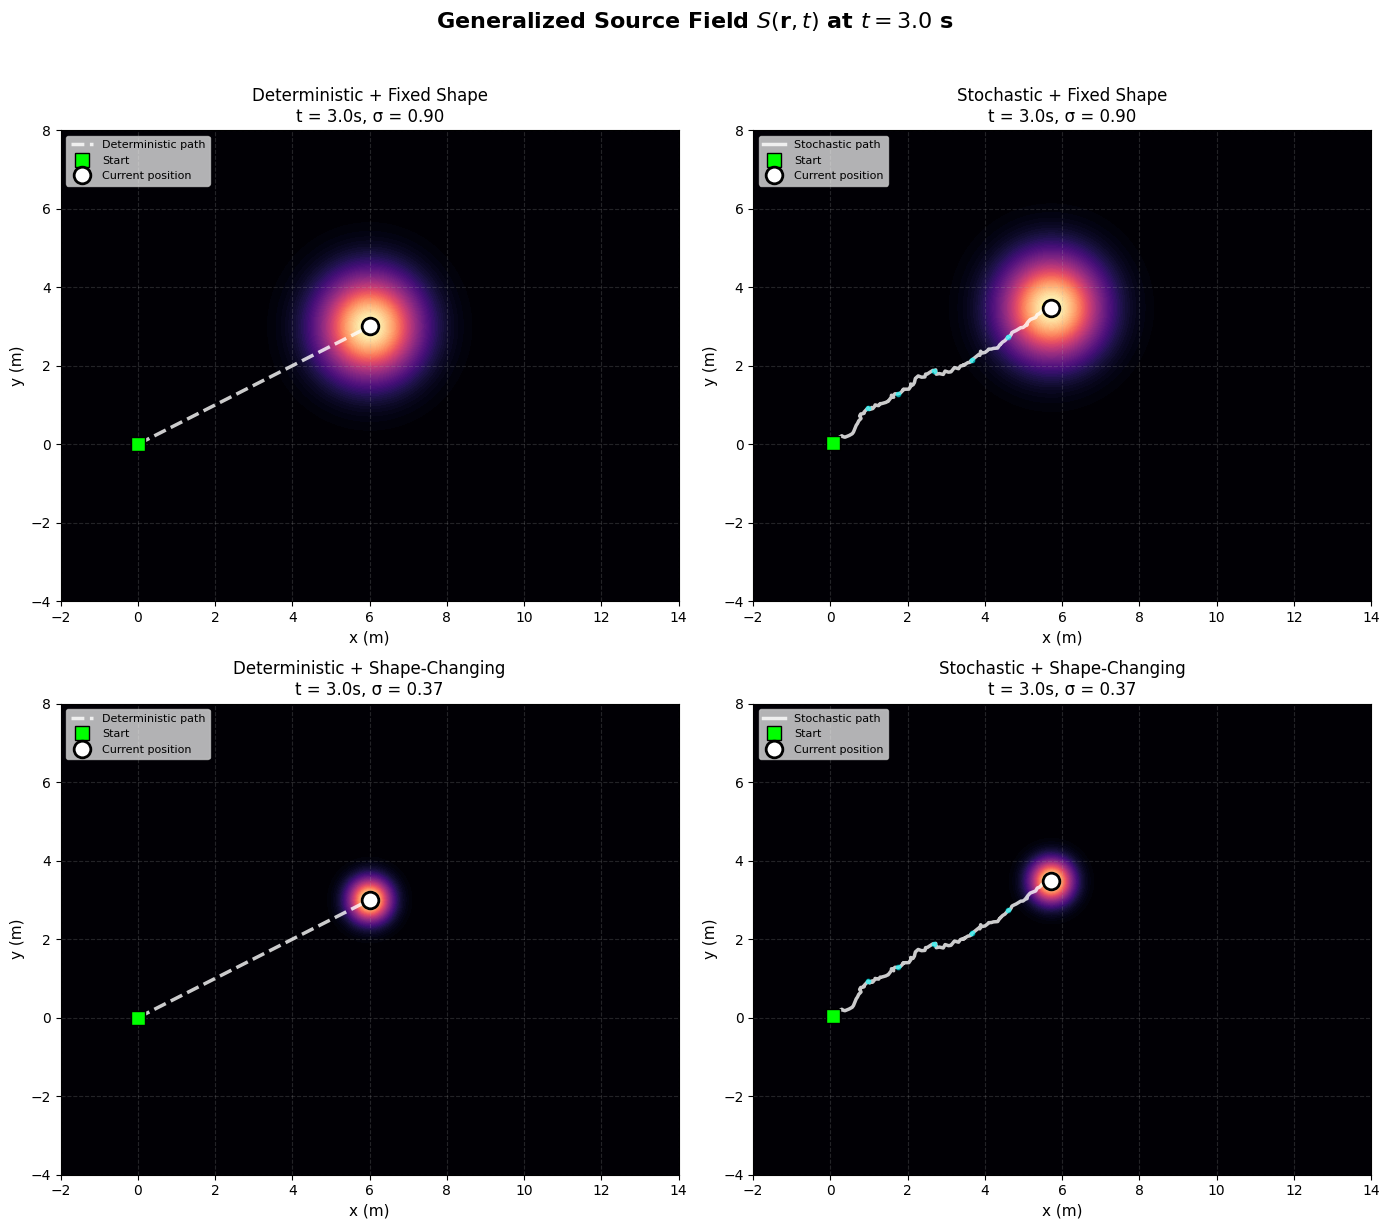

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
F0 = 19.0
x0, y0 = 0.0, 0.0
sigma0 = 0.9

# Grid
x = np.linspace(-2, 14, 200)
y = np.linspace(-4, 8, 200)
X, Y = np.meshgrid(x, y)

t = 3.0

# Generate stochastic trajectory with stronger fluctuations
np.random.seed(42)
n_steps = 200
dt_total = 5.0
dt = dt_total / n_steps
sigma_v = 1.5
vx_noise = np.random.randn(n_steps) * sigma_v
vy_noise = np.random.randn(n_steps) * sigma_v
vx_mean = 2.0
vy_mean = 1.0

x_traj = x0 + np.cumsum((vx_mean + vx_noise) * dt)
y_traj = y0 + np.cumsum((vy_mean + vy_noise) * dt)
idx = int(t / dt)

# Deterministic trajectory
traj_det_x = np.linspace(x0, x0 + vx_mean * t, 50)
traj_det_y = np.linspace(y0, y0 + vy_mean * t, 50)

# Case 1: Deterministic + Fixed Shape
xs1 = x0 + vx_mean * t
ys1 = y0 + vy_mean * t
sigma1 = sigma0

# Case 2: Stochastic + Fixed Shape
xs2 = x_traj[idx]
ys2 = y_traj[idx]
sigma2 = sigma0

# Case 3: Deterministic + Shape-Changing
xs3 = x0 + vx_mean * t
ys3 = y0 + vy_mean * t
sigma3 = sigma0 * (1 + 0.6 * np.sin(1.5 * t))

# Case 4: Stochastic + Shape-Changing
xs4 = x_traj[idx]
ys4 = y_traj[idx]
sigma4 = sigma0 * (1 + 0.6 * np.sin(1.5 * t))

cases = [
    (xs1, ys1, sigma1, traj_det_x, traj_det_y, 'Deterministic + Fixed Shape', False),
    (xs2, ys2, sigma2, x_traj[:idx+1], y_traj[:idx+1], 'Stochastic + Fixed Shape', True),
    (xs3, ys3, sigma3, traj_det_x, traj_det_y, 'Deterministic + Shape-Changing', False),
    (xs4, ys4, sigma4, x_traj[:idx+1], y_traj[:idx+1], 'Stochastic + Shape-Changing', True)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for ax, (xs, ys, sigma, traj_x, traj_y, title, is_stochastic) in zip(axes.flat, cases):
    r2 = (X - xs)**2 + (Y - ys)**2
    S = F0 * np.exp(-r2 / (2 * sigma**2)) / (2 * np.pi * sigma**2)
    
    im = ax.contourf(X, Y, S, levels=80, cmap='magma')
    
    if is_stochastic:
        ax.plot(traj_x, traj_y, '-', color='white', linewidth=2.5, alpha=0.8, label='Stochastic path')
        ax.scatter(traj_x[::20], traj_y[::20], color='cyan', s=10, alpha=0.5, zorder=2)
    else:
        ax.plot(traj_x, traj_y, '--', color='white', linewidth=2.5, alpha=0.8, label='Deterministic path')
    
    ax.plot(traj_x[0], traj_y[0], 's', color='lime', markersize=10, markeredgecolor='black', label='Start')
    ax.plot(xs, ys, 'o', color='white', markersize=12, markeredgewidth=2, markeredgecolor='black', label='Current position')
    
    if len(traj_x) > 1 and is_stochastic:
        dx = traj_x[-1] - traj_x[-5] if len(traj_x) > 5 else traj_x[-1] - traj_x[0]
        dy = traj_y[-1] - traj_y[-5] if len(traj_y) > 5 else traj_y[-1] - traj_y[0]
        ax.arrow(traj_x[-5], traj_y[-5], dx*0.3, dy*0.3, color='yellow', 
                head_width=0.3, head_length=0.3, alpha=0.7)
    
    ax.set_xlabel('x (m)', fontsize=11)
    ax.set_ylabel('y (m)', fontsize=11)
    ax.set_title(f'{title}\nt = {t:.1f}s, σ = {sigma:.2f}', fontsize=12)
    ax.set_xlim(-2, 14)
    ax.set_ylim(-4, 8)
    ax.grid(True, linestyle='--', alpha=0.2)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.7)


plt.suptitle('Generalized Source Field $S(\\mathbf{r}, t)$ at $t = 3.0$ s', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()



## Animation Figure 1